<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/22_Working_with_Dates_and_Times_in_Python/01_Dates%20and%20Calendars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [20]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/20_Cleaning_Data_in_Python/dataset/restaurants_L2.csv"
restaurants = pd.read_csv(url)
display(restaurants.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/20_Cleaning_Data_in_Python/dataset/restaurants_L2_dirty.csv"
restaurants_new = pd.read_csv(url)
display(restaurants_new.head())


,Unnamed: 0,name,addr,city,phone,type
0,0,arnie morton's of chicago,435 s. la cienega blv .,los angeles,3102461501,american
1,1,art's delicatessen,12224 ventura blvd.,studio city,8187621221,american
2,2,campanile,624 s. la brea ave.,los angeles,2139381447,american
3,3,fenix,8358 sunset blvd. west,hollywood,2138486677,american
4,4,grill on the alley,9560 dayton way,los angeles,3102760615,american


,Unnamed: 0,name,addr,city,phone,type
0,0,kokomo,6333 w. third st.,la,2139330773,american
1,1,feenix,8358 sunset blvd. west,hollywood,2138486677,american
2,2,parkway,510 s. arroyo pkwy .,pasadena,8187951001,californian
3,3,r-23,923 e. third st.,los angeles,2136877178,japanese
4,4,gumbo,6333 w. third st.,la,2139330358,cajun/creole


**The cutoff point**  
In this exercise, and throughout this chapter, you'll be working with the restaurants DataFrame which has data on various restaurants. Your ultimate goal is to create a restaurant recommendation engine, but you need to first clean your data.

This version of restaurants has been collected from many sources, where the cuisine_type column is riddled with typos, and should contain only italian, american and asian cuisine types. There are so many unique categories that remapping them manually isn't scalable, and it's best to use string similarity instead.

Before doing so, you want to establish the cutoff point for the similarity score using the thefuzz's process.extract() function by finding the similarity score of the most distant typo of each category.

In [6]:
%pip install thefuzz[speedup]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.7 MB/s eta 0:00:00


In [9]:
# Import process from thefuzz
from thefuzz import process



# Store the unique values of cuisine_type in unique_types
unique_types = pd.Series(restaurants['type'].unique())

# Calculate similarity of 'asian' to all values of unique_types
print(process.extract('asian', unique_types, limit = len(unique_types)))

# Calculate similarity of 'american' to all values of unique_types
print(process.extract('american', unique_types, limit = len(unique_types)))

# Calculate similarity of 'italian' to all values of unique_types
print(process.extract('italian', unique_types, limit = len(unique_types)))


#  80 is that sweet spot where you convert all incorrect typos without remapping
#  incorrect categories. Often times though, you may need to combine the techniques
#  learned in chapter 2, especially since there could be strings that make it beyond
#  our cutoff point, but are not actually a match!

[('asian', 100, 1), ('italian', 67, 2), ('american', 62, 0), ('mexican', 50, 4), ('steakhouses', 40, 6), ('cajun', 40, 8), ('southwestern', 36, 5), ('southern', 31, 7), ('coffeebar', 26, 3)]
[('american', 100, 0), ('mexican', 80, 4), ('cajun', 68, 8), ('asian', 62, 1), ('italian', 53, 2), ('southwestern', 49, 5), ('southern', 38, 7), ('coffeebar', 24, 3), ('steakhouses', 21, 6)]
[('italian', 100, 2), ('asian', 67, 1), ('american', 53, 0), ('mexican', 43, 4), ('cajun', 33, 8), ('southwestern', 33, 5), ('steakhouses', 33, 6), ('southern', 27, 7), ('coffeebar', 12, 3)]


**Remapping categories II**  
In the last exercise, you determined that the distance cutoff point for remapping typos of 'american', 'asian', and 'italian' cuisine types stored in the cuisine_type column should be 80.

In this exercise, you're going to put it all together by finding matches with similarity scores equal to or higher than 80 by using fuzywuzzy.process's extract() function, for each correct cuisine type, and replacing these matches with it. Remember, when comparing a string with an array of strings using process.extract(), the output is a list of tuples where each is formatted like:

`(closest match, similarity score, index of match)`  

The restaurants DataFrame is in your environment, and you have access to a categories list containing the correct cuisine types ('italian', 'asian', and 'american').

In [11]:
# Example of using process.extract to find matches
matches = process.extract('italian', restaurants['type'], limit=len(restaurants['type']))

# Inspect the first 5 matches
print(matches[0:5])

[('italian', 100, 6), ('italian', 100, 10), ('italian', 100, 11), ('italian', 100, 16), ('italian', 100, 19)]


In [16]:
# Create a list of matches, comparing 'italian' with the cuisine_type column
matches = process.extract('italian', restaurants['type'], limit=len(restaurants['type']))

# Iterate through the list of matches to italian
for match in matches:
  # Check whether the similarity score is greater than or equal to 80
  if match[1] >= 80:
    # Select all rows where the cuisine_type is spelled this way, and set them to the correct cuisine
    restaurants.loc[restaurants["type"] == match[0], 'type'] = "italian"

In [23]:
# Iterate through categories
for cuisine in categories:
  # Create a list of matches, comparing cuisine with the cuisine_type column
  matches = process.extract(cuisine, restaurants['type'], limit=len(restaurants['type']))

  # Iterate through the list of matches
  for match in matches:
     # Check whether the similarity score is greater than or equal to 80
    if match[1] >= 80:
      # If it is, select all rows where the cuisine_type is spelled this way, and set them to the correct cuisine
      restaurants.loc[restaurants['type'] == match[0]] = cuisine

# Inspect the final result
print(restaurants['type'].unique())


# All your cuisine types are properly mapped! Now you'll build on string similarity, by jumping into record linkage!

['american' 'asian' 'italian' 'coffeebar' 'southwestern' 'steakhouses'
 'southern' 'cajun']


## Record Linkage

**To link or not to link?**  
Similar to joins, record linkage is the act of linking data from different sources regarding the same entity. But unlike joins, record linkage does not require exact matches between different pairs of data, and instead can find close matches using string similarity. This is why record linkage is effective when there are no common unique keys between the data sources you can rely upon when linking data sources such as a unique identifier.

In this exercise, you will classify each card whether it is a traditional join problem, or a record linkage one.

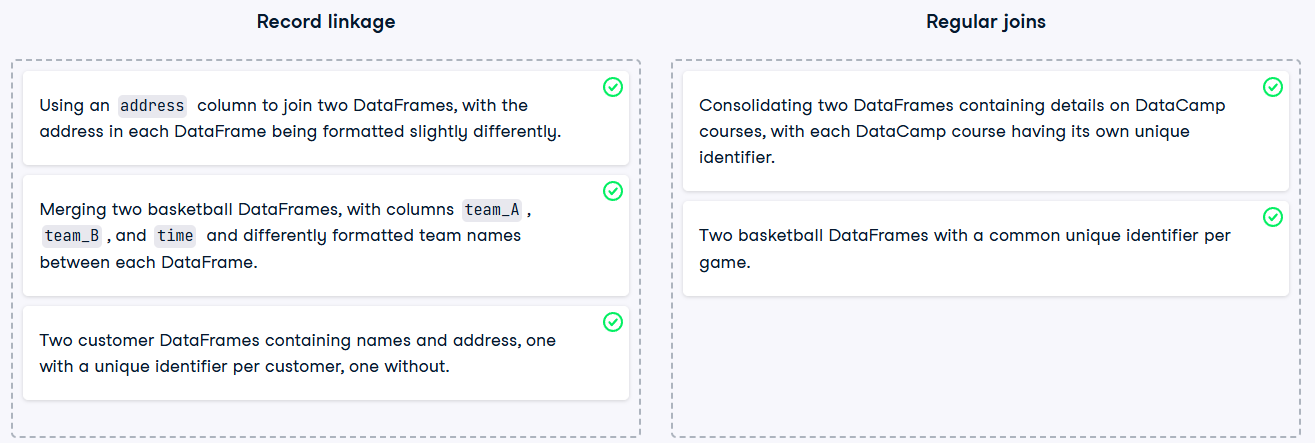

[ Don't make things more complicated than they need to be: record linkage is a powerful tool, but it's more complex than using a traditional join. ]

**Pairs of restaurants**  
In the last lesson, you cleaned the restaurants dataset to make it ready for building a restaurants recommendation engine. You have a new DataFrame named restaurants_new with new restaurants to train your model on, that's been scraped from a new data source.

You've already cleaned the cuisine_type and city columns using the techniques learned throughout the course. However you saw duplicates with typos in restaurants names that require record linkage instead of joins with restaurants.

In this exercise, you will perform the first step in record linkage and generate possible pairs of rows between restaurants and restaurants_new. Both DataFrames, pandas and recordlinkage are in your environment.

In [25]:
%pip install recordlinkage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 22.4 MB/s eta 0:00:00


In [29]:
import recordlinkage

# Create an indexer and object and find possible pairs
indexer = recordlinkage.Index()

# Block pairing on cuisine_type
indexer.block('type')

# Generate pairs
pairs = indexer.index(restaurants, restaurants_new)

**Similar restaurants**  
In the last exercise, you generated pairs between restaurants and restaurants_new in an effort to cleanly merge both DataFrames using record linkage.

When performing record linkage, there are different types of matching you can perform between different columns of your DataFrames, including exact matches, string similarities, and more.

Now that your pairs have been generated and stored in pairs, you will find exact matches in the city and cuisine_type columns between each pair, and similar strings for each pair in the rest_name column. Both DataFrames, pandas and recordlinkage are in your environment.

In [32]:
# Create a comparison object
comp_cl = recordlinkage.Compare()

# Find exact matches on city, cuisine_types -
comp_cl.exact('city', 'city', label='city')
comp_cl.exact('type', 'type', label='type')

# Find similar matches of rest_name
comp_cl.string('name', 'name', label='name', threshold = 0.8)

# Get potential matches and print
potential_matches = comp_cl.compute(pairs, restaurants, restaurants_new)
print(potential_matches)

# For this example, tightening your selection criteria will ensure good duplicate
# finds! In the next lesson, you're gonna build on what you learned to link these two DataFrames!

        city  type  name
0   0      0     1   0.0
    1      0     1   0.0
    7      0     1   0.0
    12     0     1   0.0
    13     0     1   0.0
...      ...   ...   ...
334 79     0     1   0.0
335 26     0     1   0.0
    65     0     1   0.0
    71     0     1   0.0
    79     0     1   0.0

[3784 rows x 3 columns]


**Question**
Print out potential_matches, the columns are the columns being compared, with values being 1 for a match, and 0 for not a match for each pair of rows in your DataFrames. To find potential matches, you need to find rows with more than matching value in a column. You can find them with

`potential_matches[potential_matches.sum(axis = 1) >= n]`

Where n is the minimum number of columns you want matching to ensure a proper duplicate find, what do you think should the value of n be?


- --3 because I need to have matches in all my columns.

- 2 because matching on any of the 2 columns or more is enough to find potential duplicates.

- 1 because matching on just 1 column like the restaurant name is enough to find potential duplicates.

**Linking them together!**   
In the last lesson, you've finished the bulk of the work on your effort to link restaurants and restaurants_new. You've generated the different pairs of potentially matching rows, searched for exact matches between the cuisine_type and city columns, but compared for similar strings in the rest_name column. You stored the DataFrame containing the scores in potential_matches.

Now it's finally time to link both DataFrames. You will do so by first extracting all row indices of restaurants_new that are matching across the columns mentioned above from potential_matches. Then you will subset restaurants_new on these indices, then append the non-duplicate values to restaurants. All DataFrames are in your environment, alongside pandas imported as pd.

- Isolate instances of potential_matches where the row sum is above or equal to 3 by using the .sum() method.
- Extract the second column index from matches, which represents row indices of matching record from restaurants_new by using the .get_level_values() method.
- Subset restaurants_new for rows that are not in matching_indices.
- Append non_dup to restaurants.

In [35]:
# Isolate potential matches with row sum >=3
matches = potential_matches[potential_matches.sum(axis=1) >= 3]

# Get values of second column index of matches
matching_indices = matches.index.get_level_values(1)

# Subset restaurants_new based on non-duplicate values
non_dup = restaurants_new[~restaurants_new.index.isin(matching_indices)]

# Append non_dup to restaurants
full_restaurants = pd.concat([restaurants, non_dup])
print(full_restaurants)

# Linking the DataFrames is arguably the most straightforward step of record linkage.
# You are now ready to get started on that recommendation engine!



    Unnamed: 0                       name                       addr  \
0            0  arnie morton's of chicago   435 s. la cienega blv .    
1            1         art's delicatessen       12224 ventura blvd.    
2            2                  campanile       624 s. la brea ave.    
3            3                      fenix    8358 sunset blvd. west    
4            4         grill on the alley           9560 dayton way    
..         ...                        ...                        ...   
76          76                        don        1136 westwood blvd.   
77          77                      feast        1949 westwood blvd.   
78          78                   mulberry        17040 ventura blvd.   
80          80                    jiraffe      502 santa monica blvd   
81          81                   martha's  22nd street grill 25 22nd   

                 city       phone         type  
0         los angeles  3102461501     american  
1         studio city  8187621221    